# Plot Training Results

Load the recorded metrics from the latest `training_results` run and plot them.

In [7]:
import sys
import os
import json
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.insert(0, str(Path.cwd()))

from simulator.application import Application
from simulator.infrastructure import Node


In [8]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

RESULTS_DIR = Path("training_results/run_20260328_134835")
runs = sorted([d for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.startswith("run_")])
latest_run = runs[-1] if runs else None
if not latest_run:
    print("No runs found in training_results/")
else:
    print(f"Loading metrics from {latest_run}")
    with open(latest_run / "metrics.pkl", "rb") as f:
        metrics = pickle.load(f)

    episode_total_rewards = metrics["episode_total_rewards"]
    episode_per_agent_rewards = metrics["episode_per_agent_rewards"]
    greedy_success_rates = metrics["greedy_success_rates"]
    greedy_episodes = metrics["greedy_episodes"]
    episode_workflow_violation_pct = metrics["episode_workflow_violation_pct"]
    episode_workflow_avg_latency = metrics["episode_workflow_avg_latency"]
    episode_avg_violation_pct = metrics["episode_avg_violation_pct"]
    episode_node_cpu_usage_pct = metrics["episode_node_cpu_usage_pct"]
    episode_node_avg_threads = metrics["episode_node_avg_threads"]
    N_EPISODES = metrics["N_EPISODES"]


No runs found in training_results/


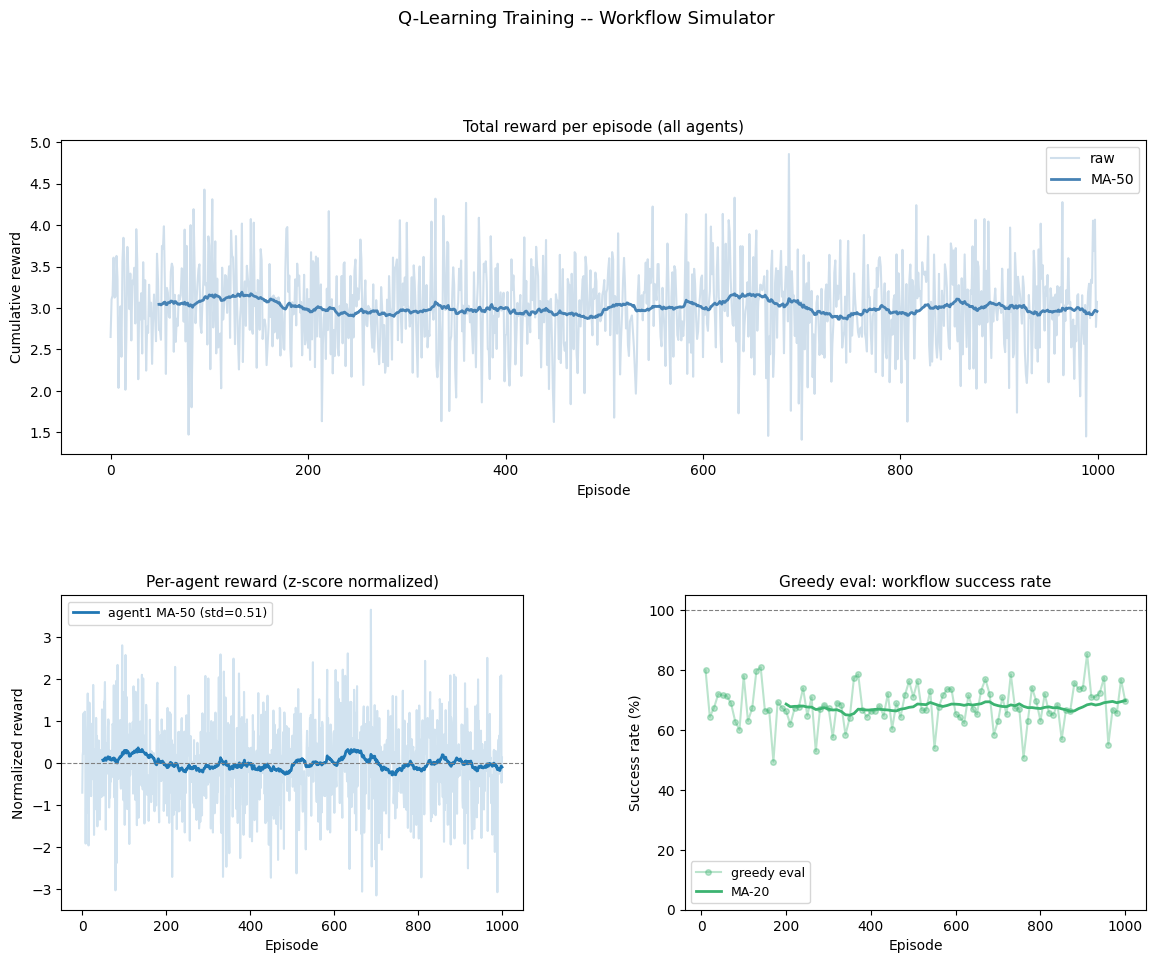

Saved -> training_curves.png


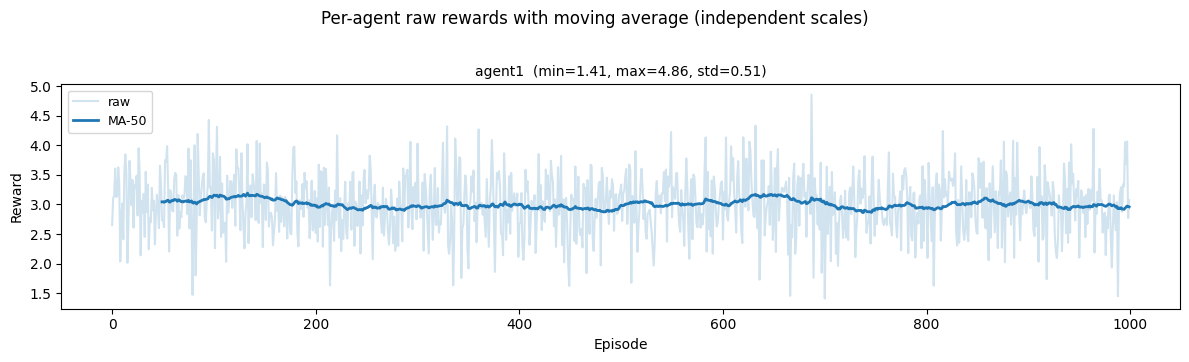

Saved -> training_curves_per_agent_raw.png


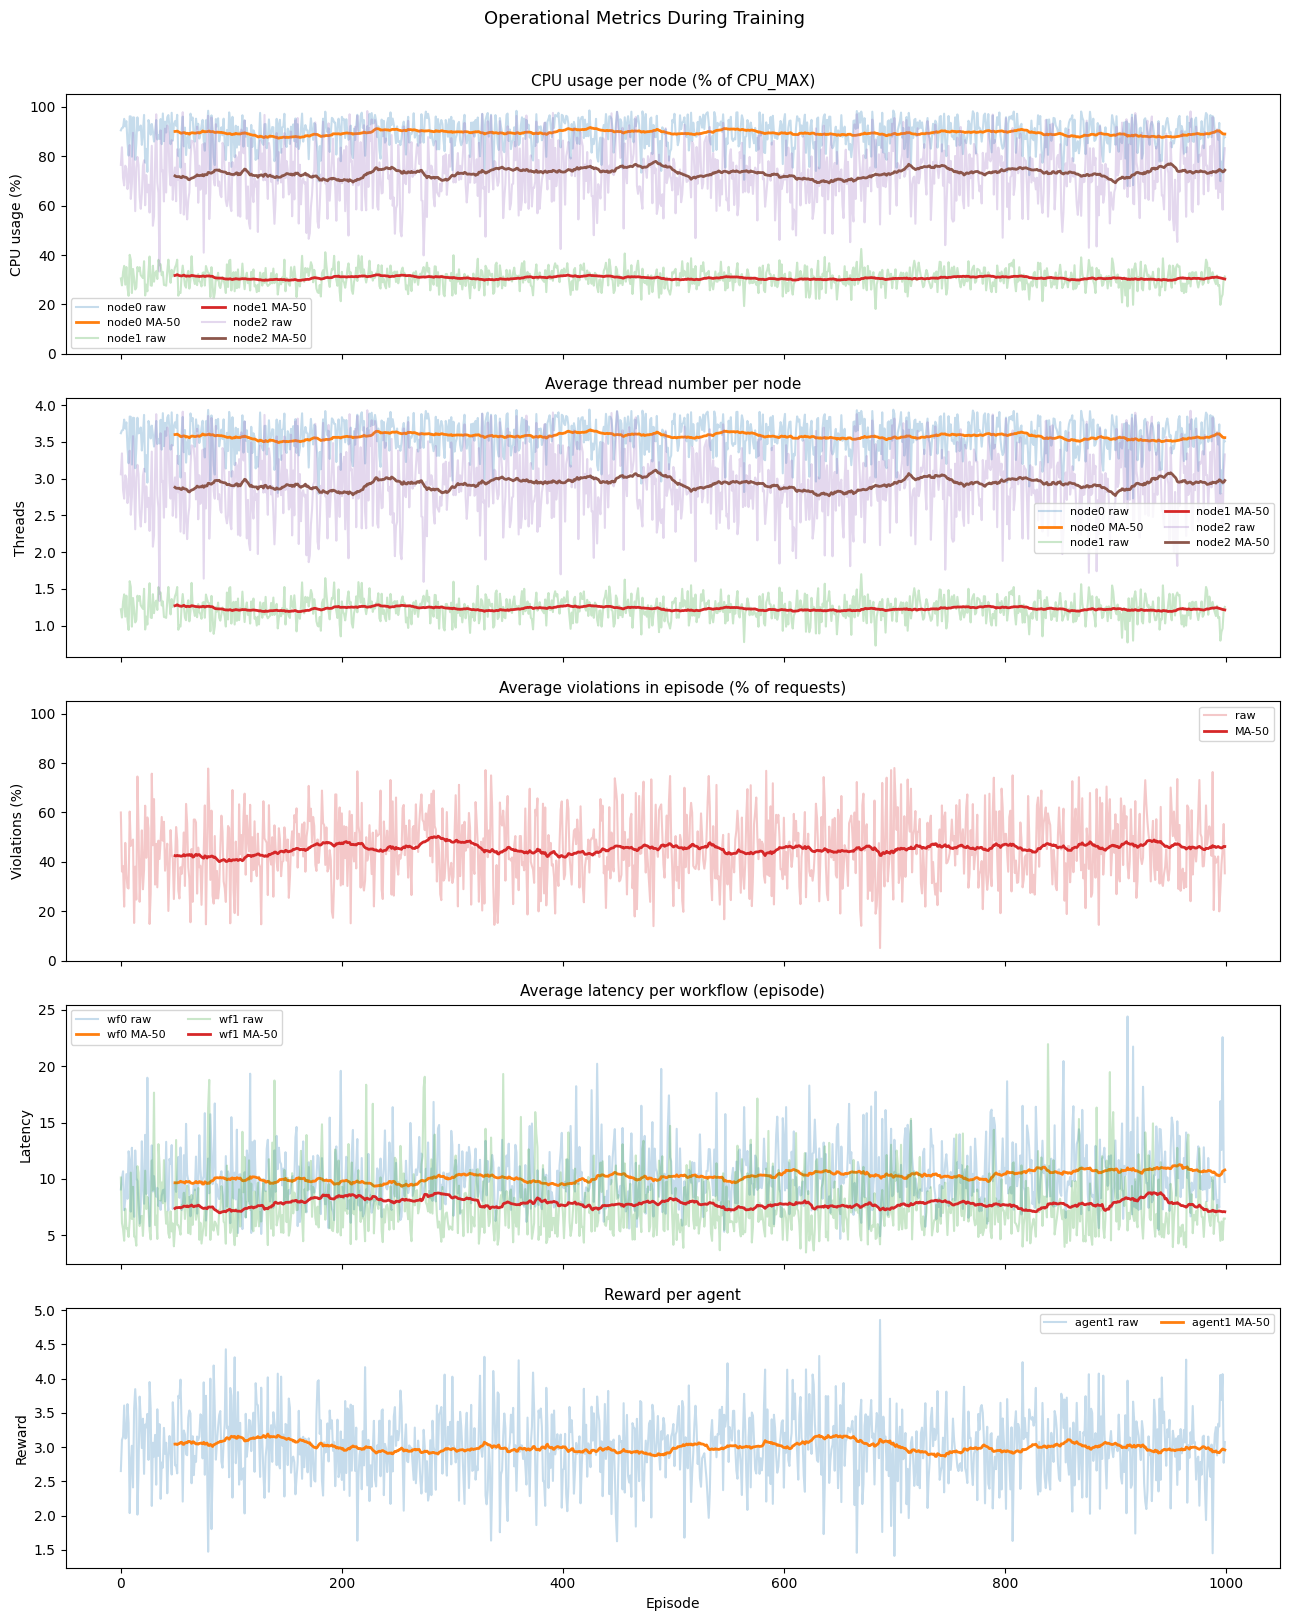

Saved -> training_metrics_requested.png


In [9]:
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

window = max(1, N_EPISODES // 20)

# -- 1. Total reward (smoothed) -----------------------------------------------
ax1 = fig.add_subplot(gs[0, :])
raw = np.array(episode_total_rewards, dtype=float)
smoothed = np.convolve(raw, np.ones(window) / window, mode="valid")
ax1.plot(raw, alpha=0.25, color="steelblue", label="raw")
ax1.plot(range(window - 1, len(raw)), smoothed, color="steelblue", linewidth=2, label=f"MA-{window}")
ax1.set_title("Total reward per episode (all agents)", fontsize=11)
ax1.set_xlabel("Episode")
ax1.set_ylabel("Cumulative reward")
ax1.legend()

# -- 2. Per-agent reward (normalized to avoid scale masking) ------------------
ax2 = fig.add_subplot(gs[1, 0])
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for idx, (agent_name, rewards) in enumerate(episode_per_agent_rewards.items()):
    arr = np.array(rewards, dtype=float)
    mu = float(arr.mean())
    sigma = float(arr.std())
    norm = (arr - mu) / (sigma + 1e-9)
    c = colors[idx % len(colors)]
    ax2.plot(norm, color=c, alpha=0.20)
    smoothed_norm = np.convolve(norm, np.ones(window) / window, mode="valid")
    ax2.plot(range(window - 1, len(norm)), smoothed_norm, color=c, linewidth=2,
             label=f"{agent_name} MA-{window} (std={sigma:.2f})")
ax2.axhline(0.0, linestyle="--", color="grey", linewidth=0.8)
ax2.set_title("Per-agent reward (z-score normalized)", fontsize=11)
ax2.set_xlabel("Episode")
ax2.set_ylabel("Normalized reward")
ax2.legend(fontsize=9)

# -- 3. Greedy success rate ----------------------------------------------------
ax3 = fig.add_subplot(gs[1, 1])
if greedy_episodes:
    ax3.plot(greedy_episodes, greedy_success_rates, marker="o", color="mediumseagreen",
             alpha=0.35, markersize=4, label="greedy eval")
    if len(greedy_success_rates) >= 3:
        gs_arr = np.array(greedy_success_rates, dtype=float)
        gs_window = max(1, len(gs_arr) // 5)
        gs_smoothed = np.convolve(gs_arr, np.ones(gs_window) / gs_window, mode="valid")
        ax3.plot(greedy_episodes[gs_window - 1:], gs_smoothed, color="mediumseagreen",
                 linewidth=2, label=f"MA-{gs_window}")
    ax3.legend(fontsize=9)
ax3.set_ylim(0, 105)
ax3.axhline(100, linestyle="--", color="grey", linewidth=0.8)
ax3.set_title("Greedy eval: workflow success rate", fontsize=11)
ax3.set_xlabel("Episode")
ax3.set_ylabel("Success rate (%)")

plt.suptitle("Q-Learning Training -- Workflow Simulator", fontsize=13, y=1.01)
plt.savefig("training_curves.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved -> training_curves.png")

# -- Additional raw per-agent figure (independent y-scales, with MA) ----------
agent_names_list = list(episode_per_agent_rewards.keys())
fig2, axes = plt.subplots(len(agent_names_list), 1, figsize=(12, 3.5 * len(agent_names_list)), sharex=True)
if len(agent_names_list) == 1:
    axes = [axes]

for i, name in enumerate(agent_names_list):
    arr = np.array(episode_per_agent_rewards[name], dtype=float)
    smoothed_raw = np.convolve(arr, np.ones(window) / window, mode="valid")
    axes[i].plot(arr, color="tab:blue", alpha=0.20, label="raw")
    axes[i].plot(range(window - 1, len(arr)), smoothed_raw, color="tab:blue", linewidth=2,
                 label=f"MA-{window}")
    axes[i].set_title(
        f"{name}  (min={arr.min():.2f}, max={arr.max():.2f}, std={arr.std():.2f})", fontsize=10
    )
    axes[i].set_ylabel("Reward")
    axes[i].legend(fontsize=9)

axes[-1].set_xlabel("Episode")
fig2.suptitle("Per-agent raw rewards with moving average (independent scales)", fontsize=12, y=1.02)
fig2.tight_layout()
fig2.savefig("training_curves_per_agent_raw.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved -> training_curves_per_agent_raw.png")

# -- Requested metrics figure ---------------------------------------------------
fig3, axes3 = plt.subplots(5, 1, figsize=(13, 16), sharex=True)

# 1) CPU usage percentage per node
for node_id in sorted(episode_node_cpu_usage_pct.keys()):
    arr = np.array(episode_node_cpu_usage_pct[node_id], dtype=float)
    axes3[0].plot(arr, alpha=0.25, label=f"node{node_id} raw")
    sm = np.convolve(arr, np.ones(window) / window, mode="valid")
    axes3[0].plot(range(window - 1, len(arr)), sm, linewidth=2, label=f"node{node_id} MA-{window}")
axes3[0].set_title("CPU usage per node (% of CPU_MAX)", fontsize=11)
axes3[0].set_ylabel("CPU usage (%)")
axes3[0].set_ylim(0.0, 105.0)
axes3[0].legend(fontsize=8, ncol=2)

# 2) Average thread number per node
for node_id in sorted(episode_node_avg_threads.keys()):
    arr = np.array(episode_node_avg_threads[node_id], dtype=float)
    axes3[1].plot(arr, alpha=0.25, label=f"node{node_id} raw")
    sm = np.convolve(arr, np.ones(window) / window, mode="valid")
    axes3[1].plot(range(window - 1, len(arr)), sm, linewidth=2, label=f"node{node_id} MA-{window}")
axes3[1].set_title("Average thread number per node", fontsize=11)
axes3[1].set_ylabel("Threads")
axes3[1].legend(fontsize=8, ncol=2)

# 3) Average violations percentage in episode
arr_viol = np.array(episode_avg_violation_pct, dtype=float)
axes3[2].plot(arr_viol, alpha=0.25, color="tab:red", label="raw")
sm_viol = np.convolve(arr_viol, np.ones(window) / window, mode="valid")
axes3[2].plot(range(window - 1, len(arr_viol)), sm_viol, linewidth=2, color="tab:red", label=f"MA-{window}")
axes3[2].set_title("Average violations in episode (% of requests)", fontsize=11)
axes3[2].set_ylabel("Violations (%)")
axes3[2].set_ylim(0.0, 105.0)
axes3[2].legend(fontsize=8)

# 4) Average latency per workflow in episode
for wf_id in sorted(episode_workflow_avg_latency.keys()):
    arr = np.array(episode_workflow_avg_latency[wf_id], dtype=float)
    axes3[3].plot(arr, alpha=0.25, label=f"wf{wf_id} raw")
    sm = np.convolve(arr, np.ones(window) / window, mode="valid")
    axes3[3].plot(range(window - 1, len(arr)), sm, linewidth=2, label=f"wf{wf_id} MA-{window}")
axes3[3].set_title("Average latency per workflow (episode)", fontsize=11)
axes3[3].set_ylabel("Latency")
axes3[3].legend(fontsize=8, ncol=2)

# 5) Reward per agent
for agent_name in sorted(episode_per_agent_rewards.keys()):
    arr = np.array(episode_per_agent_rewards[agent_name], dtype=float)
    axes3[4].plot(arr, alpha=0.25, label=f"{agent_name} raw")
    sm = np.convolve(arr, np.ones(window) / window, mode="valid")
    axes3[4].plot(range(window - 1, len(arr)), sm, linewidth=2, label=f"{agent_name} MA-{window}")
axes3[4].set_title("Reward per agent", fontsize=11)
axes3[4].set_ylabel("Reward")
axes3[4].set_xlabel("Episode")
axes3[4].legend(fontsize=8, ncol=2)

fig3.suptitle("Operational Metrics During Training", fontsize=13, y=1.01)
fig3.tight_layout()
fig3.savefig("training_metrics_requested.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved -> training_metrics_requested.png")


